### (c) Forecasting the Quarterly Umbrella Sales ($T = 20$, $S = 4$)

This section evaluates forecasting methods for a quarterly seasonal time series of umbrella sales with sample size
$T = 20$ and seasonal period $S = 4$ (five years of quarterly data). Forecast precision is measured using the last
12 observations, i.e. $t = 9,\dots,20$. 

### Methods considered

At least the following methods are considered:

1. **Seasonal Random Walk (SRW)**  
   One-step-ahead forecast:
   $$\hat{Y}_t = Y_{t-S}.$$

2. **Seasonal Random Walk plus Drift (SRW + drift)**  
   One-step-ahead forecast:
   $$\hat{Y}_t = Y_{t-S} + c_{t-1},$$
   where the drift is estimated with an expanding window as the mean seasonal difference:
   $$c_{t-1} = \frac{1}{t-S}\sum_{i=1}^{t-S}\left(Y_{S+i} - Y_i\right).$$

3. **Running Seasonal Regression (expanding-window OLS)**  
   Model with linear trend and seasonal dummies:
   $$Y_t = \mu + \beta t + \sum_{j=1}^{S}\gamma_j D_{j,t} + \varepsilon_t,$$
   with the identification constraint:
   $$\sum_{j=1}^{S}\gamma_j = 0.$$
   One-step-ahead forecasts are computed by re-estimating the regression using data up to time $t-1$ and forecasting
   $Y_t$.

4. **Seasonal Holt–Winters (Additive)**  
   State updates (level $L_t$, trend $G_t$, season $H_t$) and forecast:
   $$\hat{Y}_t = (L_{t-1} + G_{t-1}) + H_{t-S},$$
   $$L_t = \alpha (Y_t - H_{t-S}) + (1-\alpha)(L_{t-1}+G_{t-1}),$$
   $$G_t = \beta (L_t - L_{t-1}) + (1-\beta)G_{t-1},$$
   $$H_t = \gamma (Y_t - L_t) + (1-\gamma)H_{t-S}.$$

5. **Seasonal Holt–Winters (Multiplicative)**  
   Forecast:
   $$\hat{Y}_t = (L_{t-1} + G_{t-1})\,H_{t-S},$$
   Updates:
   $$L_t = \alpha \left(\frac{Y_t}{H_{t-S}}\right) + (1-\alpha)(L_{t-1}+G_{t-1}),$$
   $$G_t = \beta (L_t - L_{t-1}) + (1-\beta)G_{t-1},$$
   $$H_t = \gamma \left(\frac{Y_t}{L_t}\right) + (1-\gamma)H_{t-S}.$$

### Parameter optimization and loss function

Holt–Winters methods require $\alpha,\beta,\gamma \in (0,1)$. Parameters are optimized by minimizing the sum of
squared one-step-ahead forecast errors (SSE) on the initial subsample $t = 1,\dots,8$:

$$\text{SSE}(\alpha,\beta,\gamma) = \sum_{t=S+1}^{8}\left(Y_t - \hat{Y}_t(\alpha,\beta,\gamma)\right)^2.$$

SSE is used because it corresponds to quadratic loss and penalizes large forecast errors strongly, which is standard
in forecast evaluation.

### Forecast precision metrics (last 12 observations)

Forecast precision is computed over the last 12 observations $t = 9,\dots,20$ using:

$$\text{ME} = \frac{1}{n}\sum_{t=9}^{20} (Y_t - \hat{Y}_t), \qquad
\text{MAE} = \frac{1}{n}\sum_{t=9}^{20} |Y_t - \hat{Y}_t|,$$

$$\text{MAPE} = \frac{100}{n}\sum_{t=9}^{20} \left|\frac{Y_t - \hat{Y}_t}{Y_t}\right|, \qquad
\text{MSE} = \frac{1}{n}\sum_{t=9}^{20} (Y_t - \hat{Y}_t)^2,$$

where $n = 12$. A table reports these metrics for each method, and plots compare one-step-ahead fitted forecasts to
realized values, with a vertical line marking the start of the evaluation window at $t = 9$.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ---- import helper functions ----
from helper import (
    seasonal_random_walk_forecast,
    seasonal_random_walk_with_drift_forecast,
    running_seasonal_regression_forecast,
    holt_winters_additive_forecast,
    holt_winters_multiplicative_forecast,
    metrics_row,
    estimate_alpha_beta_gamma_seasonal_hw
)

In [2]:
# ============================================================
# Load data
# ============================================================
df = pd.read_excel("Umbrella.xlsx")
# Take numeric columns and then pick column index 1.
y = df.select_dtypes(include="number").iloc[:, 1].to_numpy(dtype=float)
T = len(y)
S = 4

# Evaluation window: last 12 observations => t = 9..20 (1-based)
# 0-based index start = 8
eval_start = T - 12  # = 8 when T=20

# Training window for parameter tuning: first 8 observations (t = 1..8)
# train_end = S * 2  # 8 for quarterly, required by HW initialization
# y_train = y[:train_end]

In [3]:
df

,Unnamed: 0,SeasIdx,Umbrella Sales
0,1(1),1,125
1,1(2),2,153
2,1(3),3,106
3,1(4),4,88
4,2(1),1,118
5,2(2),2,161
6,2(3),3,133
7,2(4),4,102
8,3(1),1,138
9,3(2),2,144


In [4]:
# ============================================================
# 1) Seasonal Random Walk (one-step-ahead)
# ============================================================
yhat_srw = seasonal_random_walk_forecast(y, S)

# ============================================================
# 2) Seasonal Random Walk + Drift (one-step-ahead, expanding)
# ============================================================
yhat_srw_drift, c_hat = seasonal_random_walk_with_drift_forecast(y, S)

# ============================================================
# 3) Running Seasonal Regression (one-step-ahead, expanding)
# ============================================================
yhat_reg, mu_hat, b_hat, g_hat = running_seasonal_regression_forecast(y, S)


# ============================================================
# 4) Holt–Winters Additive (expanding-window, re-estimated each step)
#    For each time t:
#      - use history y[:t] to grid-search (alpha, beta, gamma) that minimizes SSE
#      - produce a one-step-ahead forecast for Y_t (using data up to t-1 only)
#    Outputs:
#      aA[t], bA[t], gA[t]  -> chosen parameters at time t (NaN when undefined)
#      yhat_hw_add[t]       -> one-step-ahead forecast for Y_t
#      u_add[t]             -> forecast error: Y_t - yhat_hw_add[t]
#      loss_add[t]          -> best (minimized) in-sample SSE at time t
# ============================================================
aA, bA, gA, yhat_hw_add, u_add, loss_add = estimate_alpha_beta_gamma_seasonal_hw(
    y,
    S,
    multiplicative=False,   # additive seasonality
    criterion="SSE",        # optimize parameters by minimizing SSE
    grid_n=31,              # grid resolution for alpha/beta/gamma
    eps=1e-2                # restrict grid to (eps, 1-eps)
)

# ============================================================
# 5) Holt–Winters Multiplicative (expanding-window, re-estimated each step)
#    Same procedure as (4), but seasonality is multiplicative:
#      Ŷ_t = (level + trend) * seasonal_factor
#    Outputs are analogous:
#      aM[t], bM[t], gM[t], yhat_hw_mul[t], u_mul[t], loss_mul[t]
# ============================================================
aM, bM, gM, yhat_hw_mul, u_mul, loss_mul = estimate_alpha_beta_gamma_seasonal_hw(
    y,
    S,
    multiplicative=True,    # multiplicative seasonality
    criterion="SSE",
    grid_n=31,
    eps=1e-2
)

# ============================================================
# Metrics table on last 12 observations (t = 9..20)
# ============================================================
methods = {
    "Seasonal RW": yhat_srw,
    "Seasonal RW + Drift": yhat_srw_drift,
    "Running Seasonal Regression": yhat_reg,
    "HW Additive (expanding)": yhat_hw_add,
    "HW Multiplicative (expanding)": yhat_hw_mul,
}

rows = []
for name, yhat in methods.items():
    m = metrics_row(y, yhat, start_idx=eval_start)
    rows.append({"Method": name, **m})

In [5]:
metrics_df = pd.DataFrame(rows).sort_values("MSE", ascending=True)
print("\n=== Forecast precision on last 12 observations (t=9..20) ===")
print(metrics_df.to_string(index=False))


=== Forecast precision on last 12 observations (t=9..20) ===
                       Method        ME       MAE      MAPE         MSE
                  Seasonal RW  0.416667 18.416667 15.702240  404.250000
          Seasonal RW + Drift -2.684776 19.653385 16.996062  483.471448
HW Multiplicative (expanding) -5.030488 27.244326 23.868350 1032.370170
      HW Additive (expanding) -4.091293 28.004337 24.498643 1060.071346
  Running Seasonal Regression 26.504699 38.667109 37.709624 3618.599172


This figure compares the realized umbrella sales with one-step-ahead forecasts from all methods.
The vertical line indicates the start of the evaluation window ($t=9$).

### Forecast Precision on the Last 12 Observations ($t = 9,\dots,20$)

The table below reports out-of-sample forecast accuracy for all considered methods, evaluated using the final 12 quarterly observations. Forecasts are one-step-ahead and parameters are estimated using expanding windows where applicable.

| Method | ME | MAE | MAPE | MSE |
|------|----:|----:|-----:|----:|
| Seasonal Random Walk | 0.42 | **18.42** | **15.70** | **404.25** |
| Seasonal Random Walk + Drift | -2.68 | 19.65 | 17.00 | 483.47 |
| Holt–Winters (Multiplicative, expanding) | -5.03 | 27.24 | 23.87 | 1032.37 |
| Holt–Winters (Additive, expanding) | -4.09 | 28.00 | 24.50 | 1060.07 |
| Running Seasonal Regression | 26.50 | 38.67 | 37.71 | 3618.60 |



#### Interpretation

- The **Seasonal Random Walk** achieves the lowest values for **MAE**, **MAPE**, and **MSE**, indicating the highest forecast accuracy among all methods.
- Introducing a **drift term** slightly worsens performance, suggesting that seasonal growth is not sufficiently stable to improve forecasts.
- Both **Holt–Winters** specifications perform noticeably worse than simpler seasonal benchmarks, likely due to **overfitting** in a short sample with only five years of data.
- **Running Seasonal Regression** performs the worst, driven by a large positive mean error and high variance, reflecting unstable trend estimation in small samples.



#### Conclusion

For the quarterly umbrella sales series, **simple seasonal benchmark models dominate more complex alternatives**. The results support selecting the **Seasonal Random Walk** as the preferred forecasting method for this dataset.


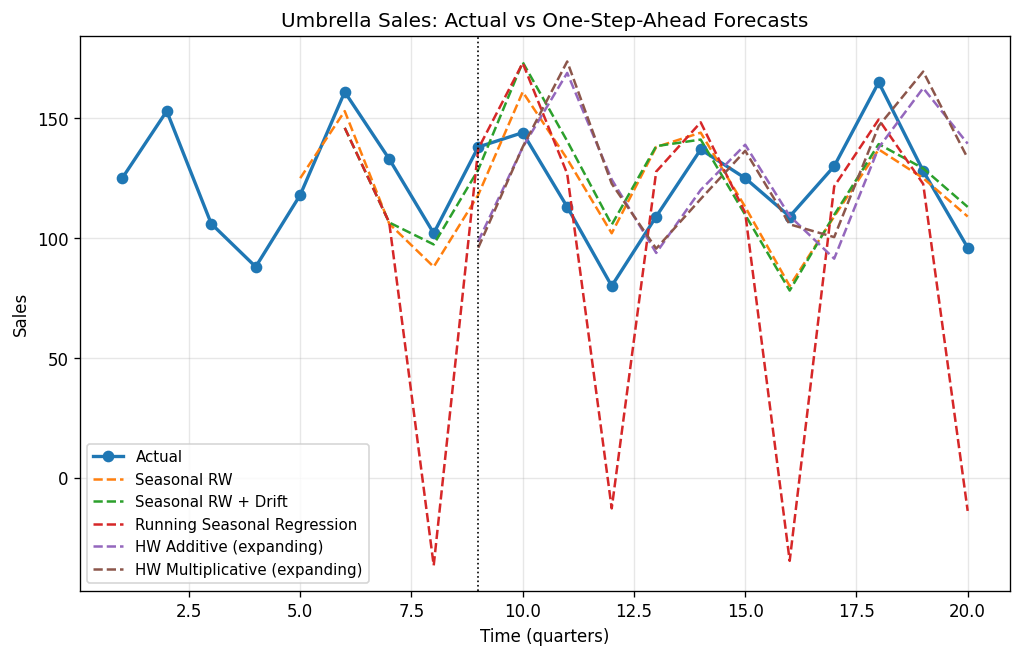

In [6]:
t = np.arange(1, T + 1)

plt.figure(figsize=(10, 6), dpi=120)

# actual data
plt.plot(t, y, marker="o", linewidth=2, label="Actual")

# forecasts
plt.plot(t, yhat_srw, linestyle="--", label="Seasonal RW")
plt.plot(t, yhat_srw_drift, linestyle="--", label="Seasonal RW + Drift")
plt.plot(t, yhat_reg, linestyle="--", label="Running Seasonal Regression")
plt.plot(t, yhat_hw_add, linestyle="--", label="HW Additive (expanding)")
plt.plot(t, yhat_hw_mul, linestyle="--", label="HW Multiplicative (expanding)")

# mark evaluation window start (t = 9)
plt.axvline(eval_start + 1, color="black", linestyle=":", linewidth=1)

plt.title("Umbrella Sales: Actual vs One-Step-Ahead Forecasts")
plt.xlabel("Time (quarters)")
plt.ylabel("Sales")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()

This figure displays one-step-ahead forecast errors over the evaluation period.
The Seasonal Random Walk exhibits the smallest and most stable errors, while more complex methods show larger deviations.

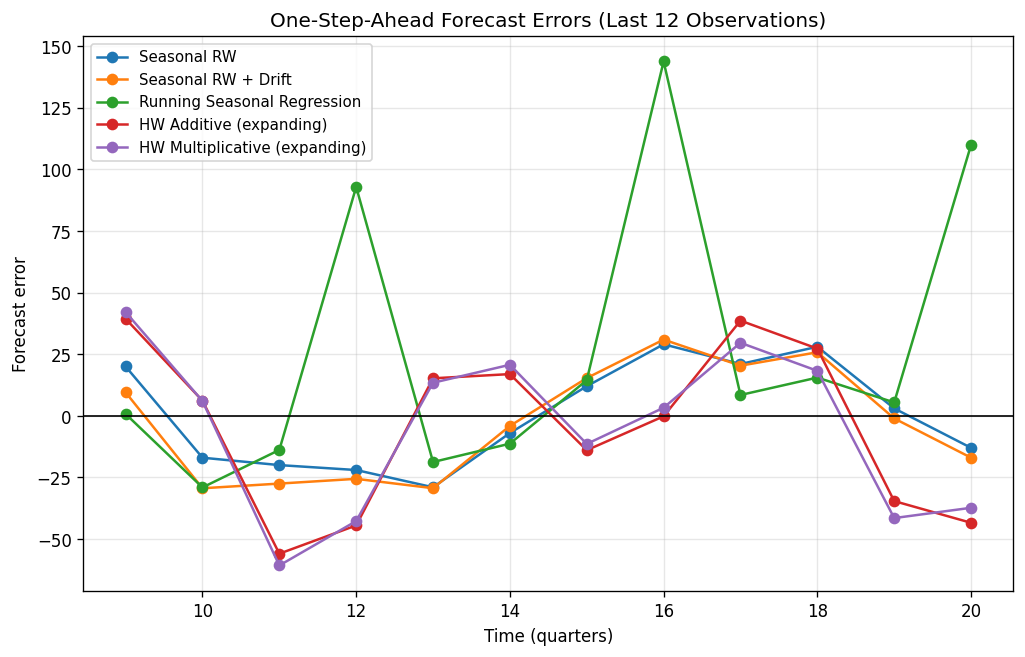

In [7]:
plt.figure(figsize=(10, 6), dpi=120)

t_eval = t[eval_start:]

plt.plot(t_eval, y[eval_start:] - yhat_srw[eval_start:], marker="o", label="Seasonal RW")
plt.plot(t_eval, y[eval_start:] - yhat_srw_drift[eval_start:], marker="o", label="Seasonal RW + Drift")
plt.plot(t_eval, y[eval_start:] - yhat_reg[eval_start:], marker="o", label="Running Seasonal Regression")
plt.plot(t_eval, y[eval_start:] - yhat_hw_add[eval_start:], marker="o", label="HW Additive (expanding)")
plt.plot(t_eval, y[eval_start:] - yhat_hw_mul[eval_start:], marker="o", label="HW Multiplicative (expanding)")

plt.axhline(0, color="black", linewidth=1)
plt.title("One-Step-Ahead Forecast Errors (Last 12 Observations)")
plt.xlabel("Time (quarters)")
plt.ylabel("Forecast error")
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.show()
